# EDA and Graphs for Batteries B0005, B0006, B0007, B0018

This notebook analyzes the cleaned dataset and builds the first 3 graph groups for the **first battery set**:
- **1) Capacity vs cycle index** (discharge)
- **2) Impedance trends (`Re`, `Rct`) vs cycle index**
- **3) Sample cycle signals vs time** (voltage/current/temperature)

## Step 0 - Imports and plot style

Run this first. If `pandas`/`matplotlib` are missing in your Jupyter environment, install them with pip in your notebook kernel.

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)

## Step 1 - Paths and selected batteries

We use the cleaned Kaggle dataset folder and focus only on:
`B0005`, `B0006`, `B0007`, `B0018`.

In [3]:
ROOT = Path("..")
CLEAN_ROOT = ROOT / "data_test" / "Cleaned Datasets" / "Datasets 5-56 cleaned" / "cleaned_dataset"
META_PATH = CLEAN_ROOT / "metadata.csv"
DATA_DIR = CLEAN_ROOT / "data"

SELECTED_BATTERIES = ["B0005", "B0006", "B0007", "B0018"]

print("Metadata path:", META_PATH)
print("Data dir exists:", DATA_DIR.exists())

Metadata path: ../data_test/Cleaned Datasets/Datasets 5-56 cleaned/cleaned_dataset/metadata.csv
Data dir exists: True


## Step 2 - Load metadata and basic checks

We parse `start_time` to datetime and keep only selected batteries.

In [5]:
meta = pd.read_csv(META_PATH)

import warnings
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="Could not infer format")
    meta["start_time"] = pd.to_datetime(meta["start_time"], errors="coerce")

meta_sel = meta[meta["battery_id"].isin(SELECTED_BATTERIES)].copy()

print("Total metadata rows:", len(meta))
print("Selected rows:", len(meta_sel))
print("Type counts (selected):")
print(meta_sel["type"].value_counts())

missing_files = (~meta_sel["filename"].isin([p.name for p in DATA_DIR.glob("*.csv")])).sum()
print("Missing CSV files for selected rows:", int(missing_files))


Total metadata rows: 7565
Selected rows: 2167
Type counts (selected):
type
impedance    887
charge       644
discharge    636
Name: count, dtype: int64
Missing CSV files for selected rows: 0


## Step 3 - Build cycle index per battery/type

A cycle index makes trend plots much clearer.

In [6]:
meta_sel = meta_sel.sort_values(["battery_id", "type", "start_time", "uid"], kind="mergesort")
meta_sel["cycle_index"] = meta_sel.groupby(["battery_id", "type"]).cumcount() + 1

meta_sel[["battery_id", "type", "cycle_index", "filename"]].head()

,battery_id,type,cycle_index,filename
5120,B0005,charge,1,05121.csv
5122,B0005,charge,2,05123.csv
5124,B0005,charge,3,05125.csv
5126,B0005,charge,4,05127.csv
5128,B0005,charge,5,05129.csv


## Graph 1 - Capacity vs cycle index (discharge only)

`Capacity` is meaningful for discharge cycles in this dataset.

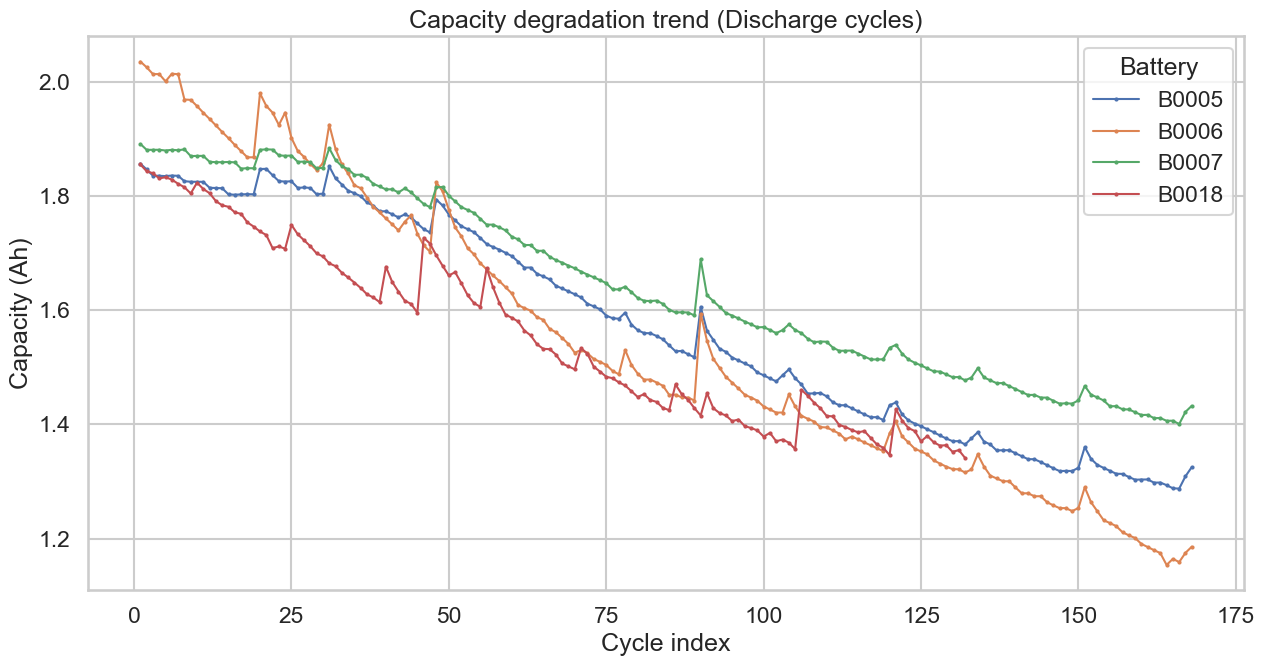

In [7]:
discharge = meta_sel[meta_sel["type"] == "discharge"].copy()
discharge["Capacity"] = pd.to_numeric(discharge["Capacity"], errors="coerce")
discharge = discharge.dropna(subset=["Capacity"])

plt.figure(figsize=(13, 7))
for bid, df_b in discharge.groupby("battery_id"):
    plt.plot(df_b["cycle_index"], df_b["Capacity"], marker="o", markersize=2, linewidth=1.5, label=bid)

plt.title("Capacity degradation trend (Discharge cycles)")
plt.xlabel("Cycle index")
plt.ylabel("Capacity (Ah)")
plt.legend(title="Battery")
plt.tight_layout()
plt.show()

## Graph 2 - Impedance trends (`Re`, `Rct`) vs cycle index

Impedance values can contain extreme outliers. We apply a light robust filter:
- keep only impedance rows
- numeric conversion
- keep values in `(0, 10]` for `Re` and `Rct`

You can relax/tighten this threshold later.

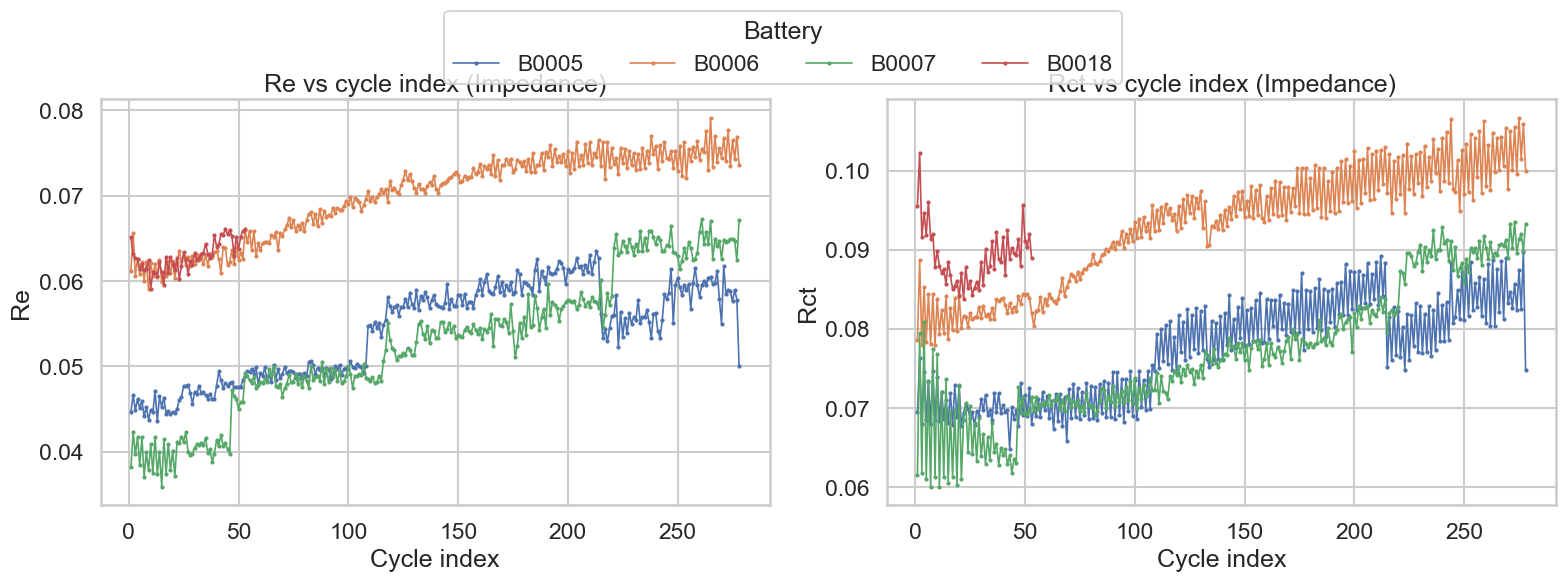

In [8]:
imp = meta_sel[meta_sel["type"] == "impedance"].copy()
imp["Re"] = pd.to_numeric(imp["Re"], errors="coerce")
imp["Rct"] = pd.to_numeric(imp["Rct"], errors="coerce")

imp_clean = imp[(imp["Re"] > 0) & (imp["Re"] <= 10) & (imp["Rct"] > 0) & (imp["Rct"] <= 10)].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=False)
for bid, df_b in imp_clean.groupby("battery_id"):
    axes[0].plot(df_b["cycle_index"], df_b["Re"], marker="o", markersize=2, linewidth=1.2, label=bid)
    axes[1].plot(df_b["cycle_index"], df_b["Rct"], marker="o", markersize=2, linewidth=1.2, label=bid)

axes[0].set_title("Re vs cycle index (Impedance)")
axes[0].set_xlabel("Cycle index")
axes[0].set_ylabel("Re")

axes[1].set_title("Rct vs cycle index (Impedance)")
axes[1].set_xlabel("Cycle index")
axes[1].set_ylabel("Rct")

handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles, labels, title="Battery", loc="upper center", ncol=4)
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

## Graph 3 - Sample time-series signals per battery

For each selected battery, we load one sample **charge** and one sample **discharge** cycle.
Then we plot:
- Voltage vs Time
- Current vs Time
- Temperature vs Time

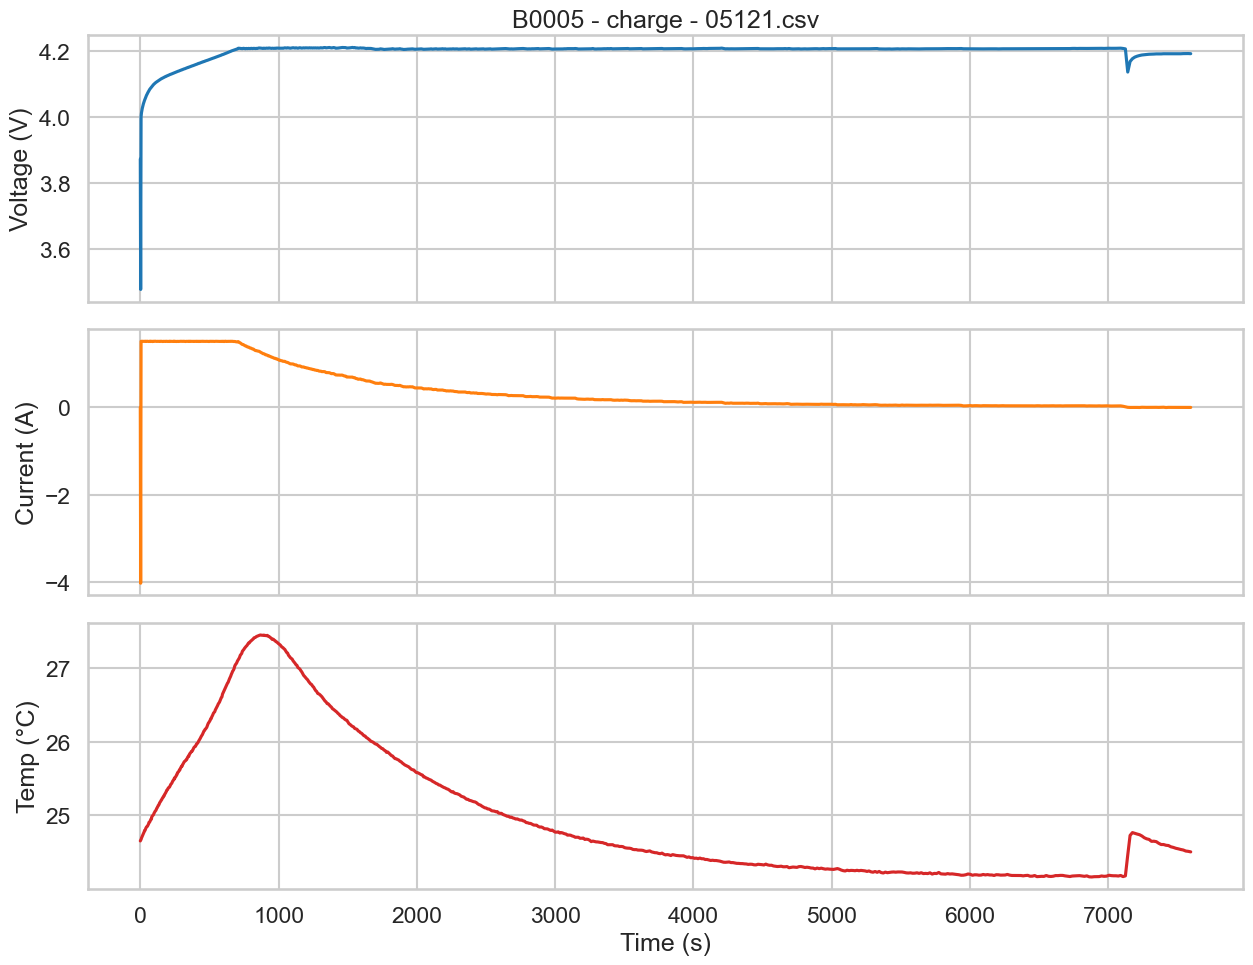

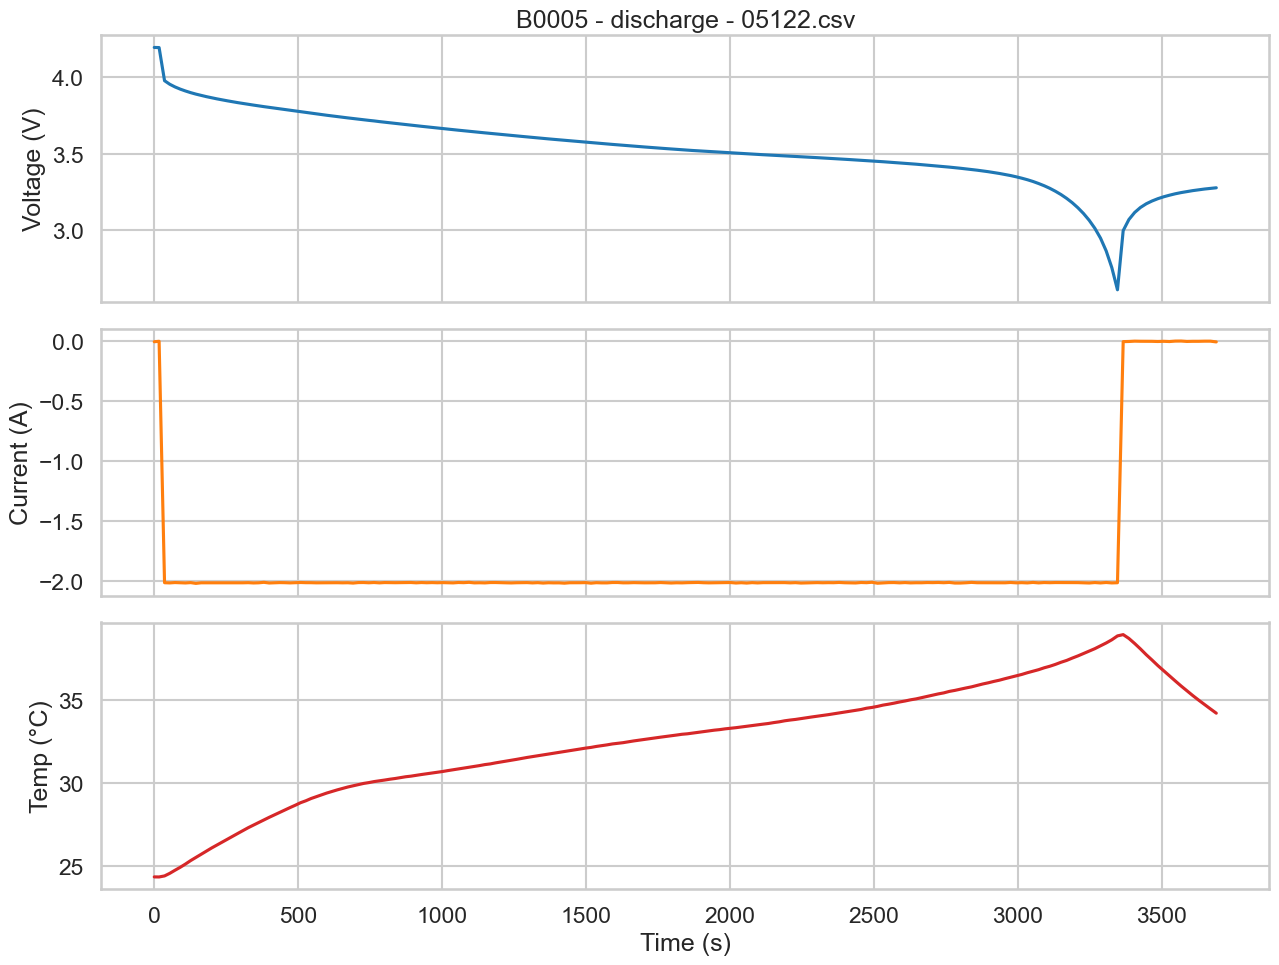

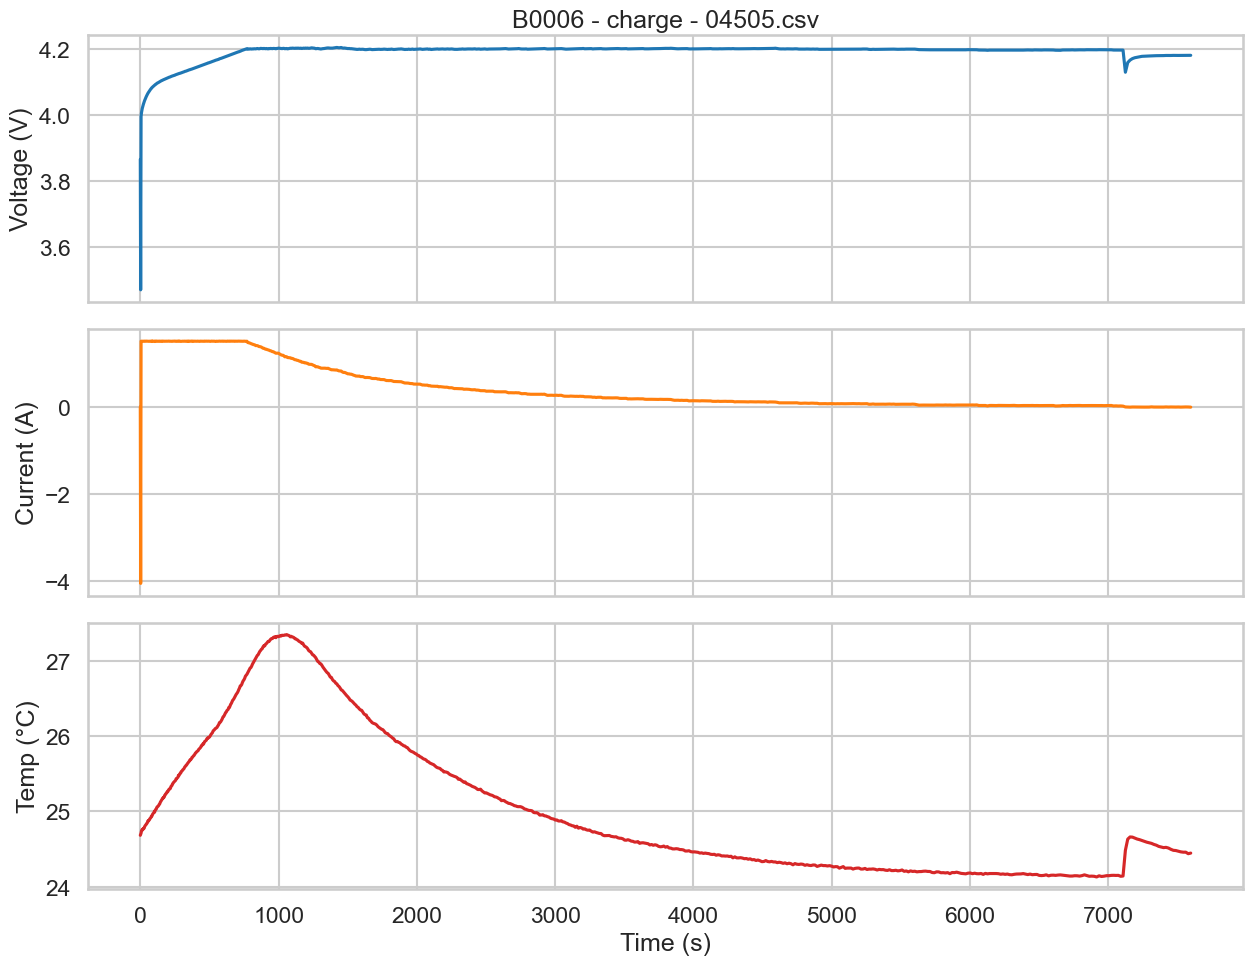

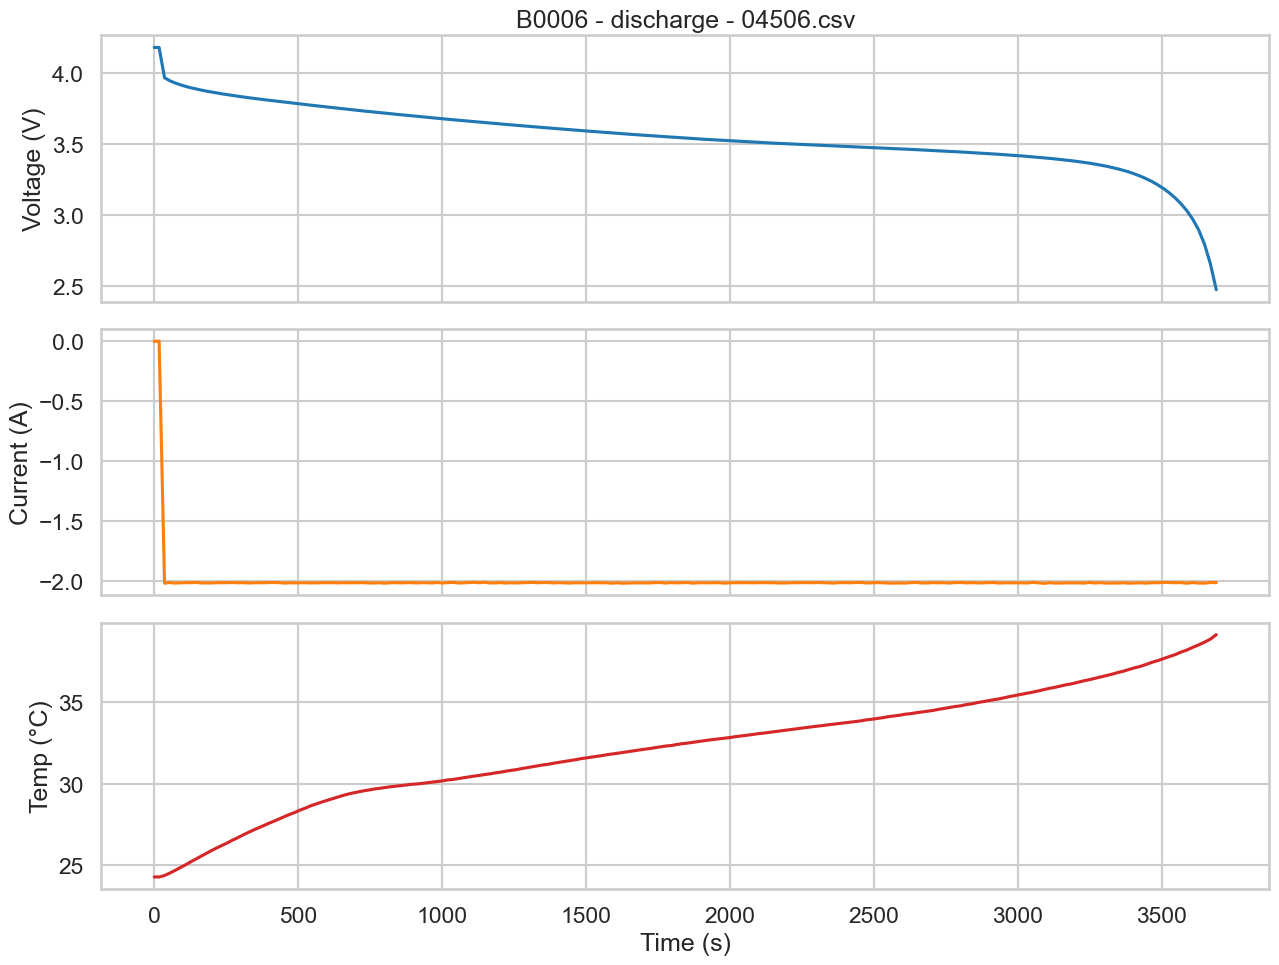

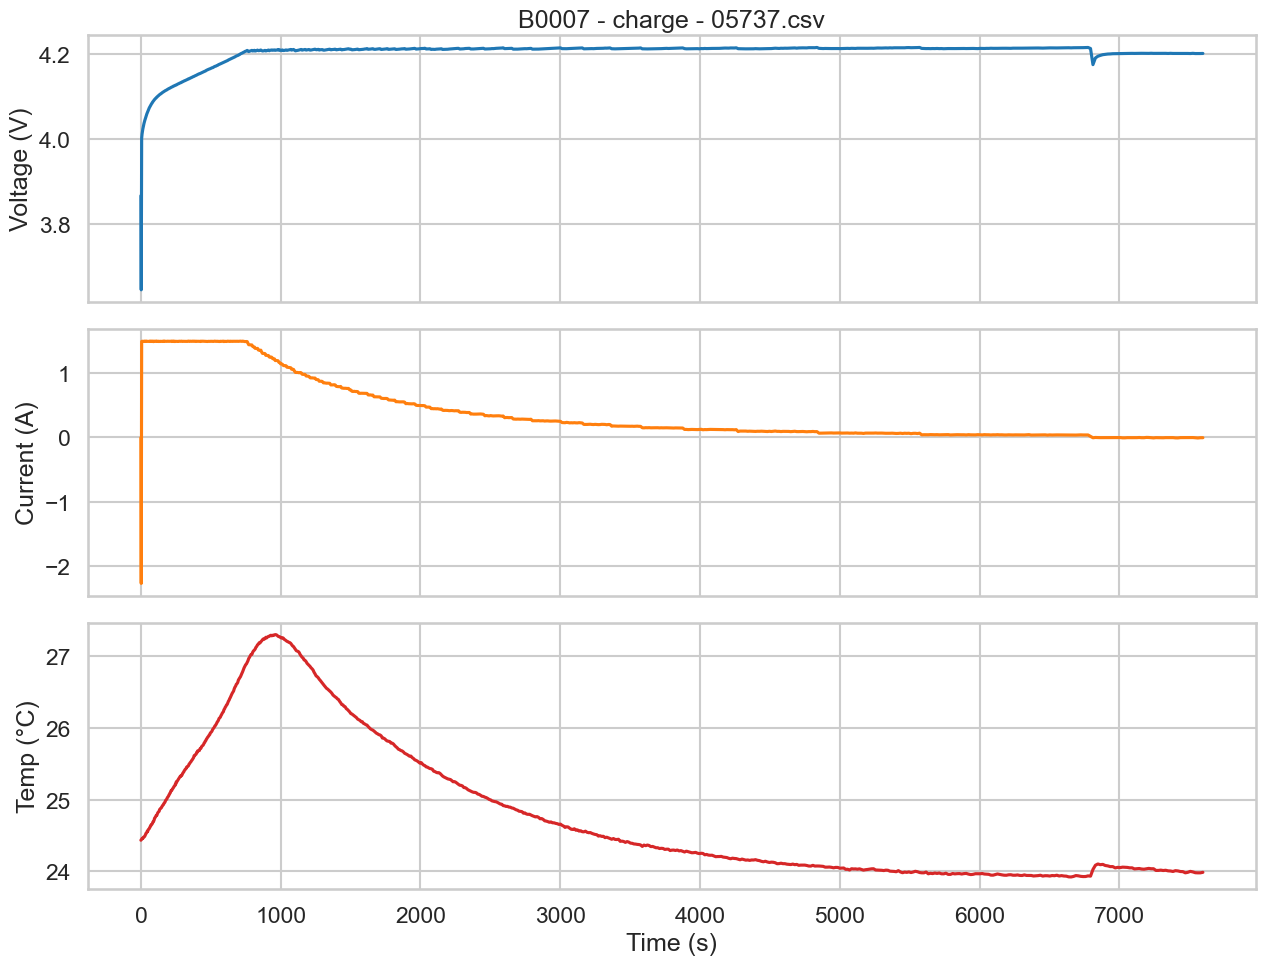

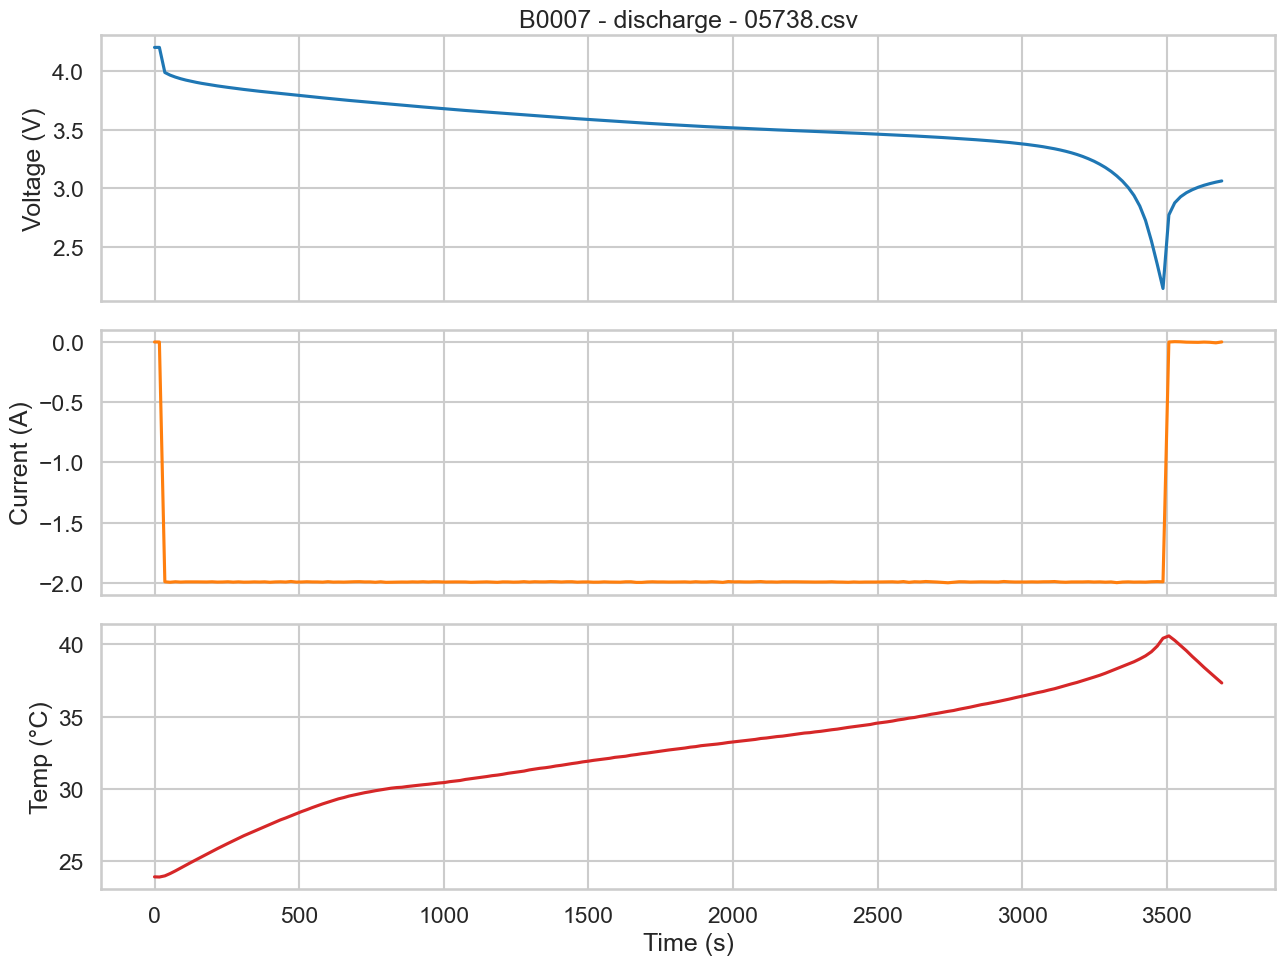

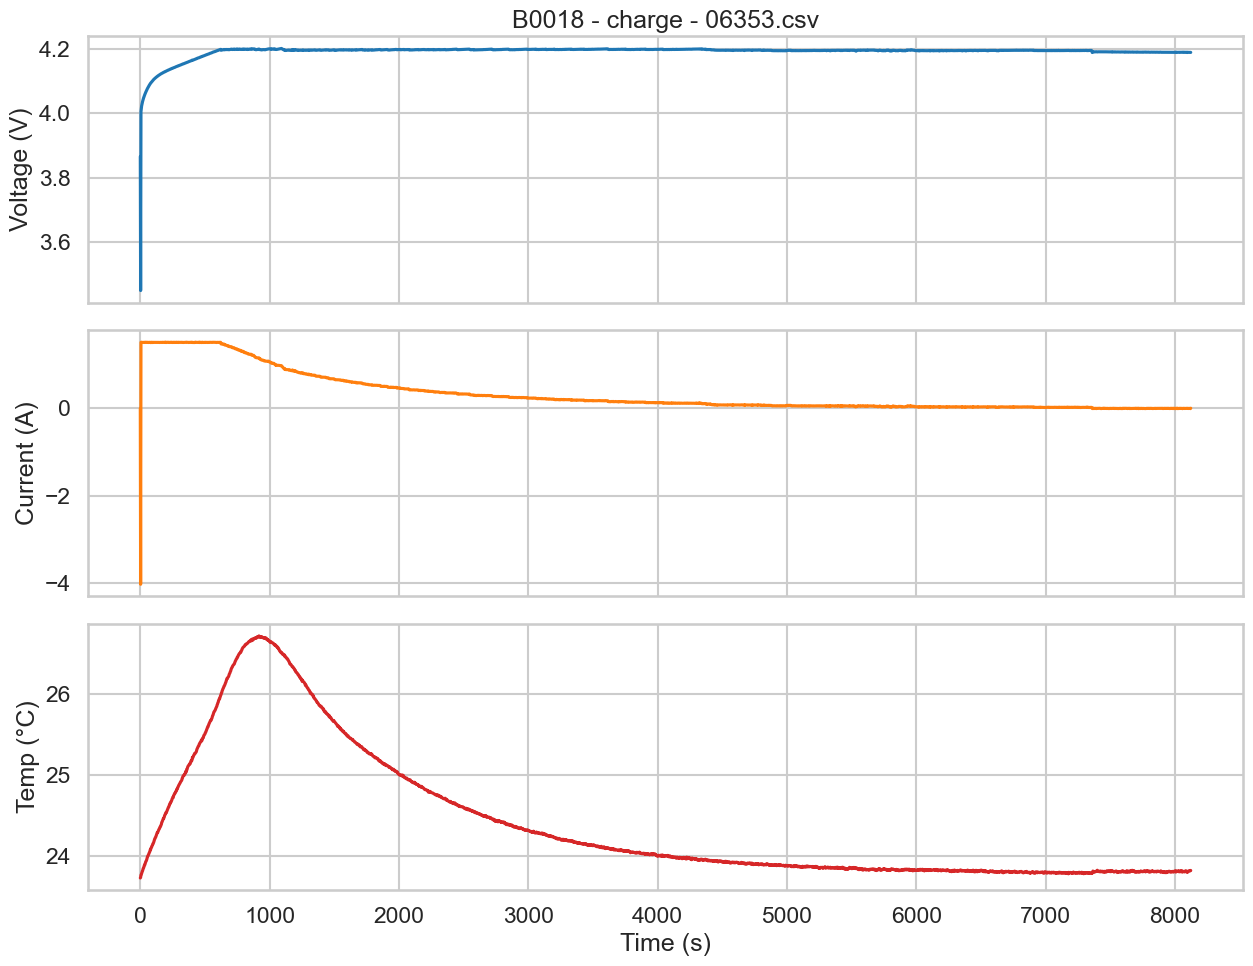

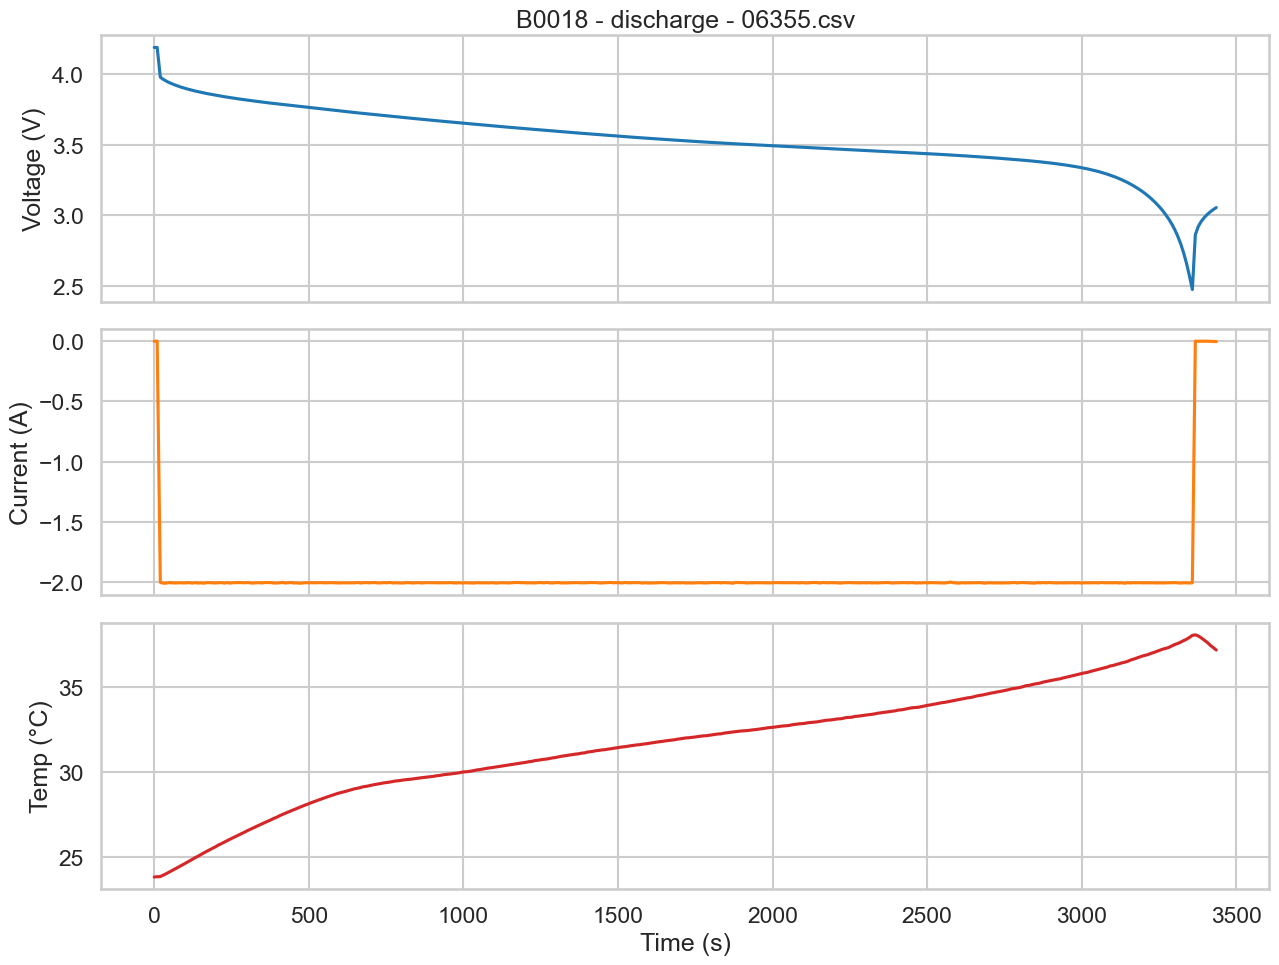

In [9]:
def first_cycle_filename(df, battery_id, cycle_type):
    sel = df[(df["battery_id"] == battery_id) & (df["type"] == cycle_type)].sort_values("cycle_index")
    if sel.empty:
        return None
    return sel.iloc[0]["filename"]

signal_cols = ["Time", "Voltage_measured", "Current_measured", "Temperature_measured"]

for battery in SELECTED_BATTERIES:
    for cyc_type in ["charge", "discharge"]:
        fname = first_cycle_filename(meta_sel, battery, cyc_type)
        if not fname:
            print(f"No {cyc_type} cycle found for {battery}")
            continue

        fpath = DATA_DIR / fname
        df = pd.read_csv(fpath)
        for col in signal_cols:
            df[col] = pd.to_numeric(df[col], errors="coerce")

        fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)
        axes[0].plot(df["Time"], df["Voltage_measured"], color="tab:blue")
        axes[0].set_ylabel("Voltage (V)")
        axes[0].set_title(f"{battery} - {cyc_type} - {fname}")

        axes[1].plot(df["Time"], df["Current_measured"], color="tab:orange")
        axes[1].set_ylabel("Current (A)")

        axes[2].plot(df["Time"], df["Temperature_measured"], color="tab:red")
        axes[2].set_ylabel("Temp (°C)")
        axes[2].set_xlabel("Time (s)")

        plt.tight_layout()
        plt.show()

## Optional - Save figures to `docs/figures`

Uncomment and adapt this cell if you want to export plots for the thesis document.

In [ ]:
# FIG_DIR = ROOT / "docs" / "figures"
# FIG_DIR.mkdir(parents=True, exist_ok=True)
# plt.figure(...)  # build plot
# plt.savefig(FIG_DIR / "capacity_b0005_b0018.png", dpi=300, bbox_inches="tight")

## Next step suggestion

After these visual checks, we can create a baseline modeling notebook (e.g. SVR) using engineered cycle-level features.